In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#TASK 1 DATA CLEANING

In [5]:
df = pd.read_csv(r"C:\Users\srv\Desktop\financial risk\morgan_stanely.csv")


In [6]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,06-01-2023,81300.425190,40843.56193,0.330474,484,13
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,17-02-2023,9269.640373,61183.03953,0.089688,836,18
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,13-09-2023,28138.552650,85460.13405,0.340010,451,25
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,28-05-2024,83943.556980,100525.35900,0.605383,487,13
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,12-05-2023,77104.456470,57425.69930,1.042441,393,10


In [7]:
df.shape #cheaking raw & column numbers

(800, 15)

In [8]:
df.columns # All column names

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths'],
      dtype='str')

In [9]:
df.info() # Display dataset information(data types, non-null values & total entries)

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    str    
 2   AccountID          800 non-null    str    
 3   AccountType        800 non-null    str    
 4   TransactionType    800 non-null    str    
 5   Product            800 non-null    str    
 6   Firm               800 non-null    str    
 7   Region             800 non-null    str    
 8   Manager            800 non-null    str    
 9   TransactionDate    800 non-null    str    
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), str(9)
memory usage: 93.9 KB


In [10]:
df.describe() # Display satistical summary of numarical column

,TransactionID,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,99.786250,55194.889273,72764.355699,0.473380,568.526250,119.870000
std,57.460793,28940.337792,35623.574024,0.239982,155.620111,67.356806
min,1.000000,-36173.695550,-62548.722060,-0.300118,306.000000,6.000000
25%,50.000000,34842.164247,48684.199043,0.312271,437.000000,63.000000
50%,99.500000,53768.493325,72908.053070,0.485829,565.000000,118.000000
75%,150.000000,74729.551358,95574.572673,0.632799,699.500000,178.000000
max,199.000000,154662.045800,180539.287700,1.254704,848.000000,238.000000


In [12]:
df.isnull().sum() # check missing values

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

In [14]:
df= df.drop_duplicates() # this task perfome for remove duplicated values(if any)

In [15]:
df["TransactionDate"]=pd.to_datetime(df["TransactionDate"],format="%d-%m-%Y") # convert datetime column

In [16]:
df.info() # Verify update data types after cleaning

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    str           
 2   AccountID          800 non-null    str           
 3   AccountType        800 non-null    str           
 4   TransactionType    800 non-null    str           
 5   Product            800 non-null    str           
 6   Firm               800 non-null    str           
 7   Region             800 non-null    str           
 8   Manager            800 non-null    str           
 9   TransactionDate    800 non-null    datetime64[us]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMonths       80

In [18]:
df.groupby("TransactionType")["TransactionAmount"].sum() # Calculate total transction amount for each transction type

TransactionType
Deposit       1.097685e+07
Payment       1.105560e+07
Transfer      1.101760e+07
Withdrawal    1.110586e+07
Name: TransactionAmount, dtype: float64

In [19]:
print(df["TransactionAmount"].head()) # chakeing data types
print(df["TransactionAmount"].dtype)  # chakeing data types

0    81300.425190
1     9269.640373
2    28138.552650
3    83943.556980
4    77104.456470
Name: TransactionAmount, dtype: float64
float64


In [21]:
# Inspect first few values of TransactionAmount to verify
for val in df['TransactionAmount'].head(5):
    print(repr(val)) 

81300.42519
9269.640373
28138.55265
83943.55698
77104.45647


In [22]:
#Convert Transaction Amount to numeric

df["TransactionAmount"] = df["TransactionAmount"].astype(float)
df["AccountBalance"] = df["AccountBalance"].astype(float)

In [24]:
#Standardize categories
df["AccountType"] = df["AccountType"].str.lower().str.strip()
df["TransactionType"] = df["TransactionType"].str.lower().str.strip()

In [25]:
df.tail(2) # cheak last 2 values

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
798,28,CUST8028,ACC61827,savings,transfer,Credit Card,Firm A,South,Manager 3,2024-03-21,31344.17885,168048.0333,0.546988,407,30
799,71,CUST8028,ACC90887,credit,payment,Personal Loan,Firm C,West,Manager 3,2024-01-29,57594.19981,138865.9396,0.419232,529,65


In [ ]:
# TASK 2 Descriptive Transactional Analysis

In [26]:
#Create Month & Year
df['Month'] = df['TransactionDate'].dt.month
df['Year'] = df['TransactionDate'].dt.year

In [27]:
df[['TransactionDate','Month','Year']].head() # cheak changes

,TransactionDate,Month,Year
0,2023-01-06,1,2023
1,2023-02-17,2,2023
2,2023-09-13,9,2023
3,2024-05-28,5,2024
4,2023-05-12,5,2023


In [28]:
#Credit vs Debit
summary = df.groupby(['Year','TransactionType'])['TransactionAmount'].sum()

In [29]:
summary # cheaking values

Year  TransactionType
2023  deposit            7.727269e+06
      payment            7.719796e+06
      transfer           7.488798e+06
      withdrawal         7.806984e+06
2024  deposit            3.249579e+06
      payment            3.335802e+06
      transfer           3.528806e+06
      withdrawal         3.298878e+06
Name: TransactionAmount, dtype: float64

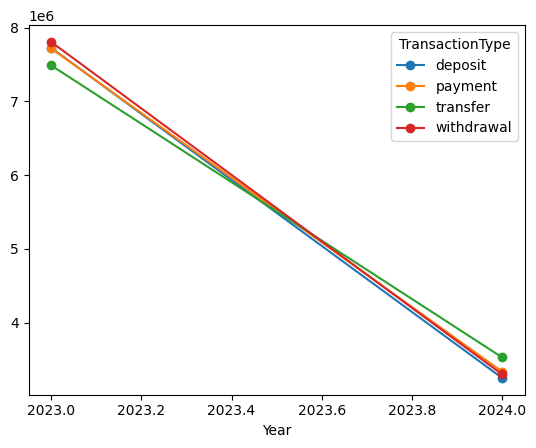

In [31]:
#vizulization of summary

summary= df.groupby(["Year","TransactionType"])["TransactionAmount"].sum().reset_index()

pivort=summary.pivot(index ="Year",columns="TransactionType",values="TransactionAmount")
pivort.plot(marker="o")
plt.show()

In [32]:
#Net Amount

df["NetAmount"] = np.where(df["TransactionType"]=="deposit", df["TransactionAmount"],-df["TransactionAmount"])

In [34]:
df[["TransactionType","TransactionAmount","NetAmount"]].head() # cheak Net Amount

,TransactionType,TransactionAmount,NetAmount
0,withdrawal,81300.425190,-81300.425190
1,withdrawal,9269.640373,-9269.640373
2,transfer,28138.552650,-28138.552650
3,payment,83943.556980,-83943.556980
4,deposit,77104.456470,77104.456470


In [35]:
#Inactive Accounts

df = df.sort_values(["AccountID","TransactionDate"])

df["Gap"] = df.groupby("AccountID")["TransactionDate"].diff().dt.days

inactive = df[df["Gap"] > 60]["AccountID"].unique()
print(inactive)

<StringArray>
['ACC10117', 'ACC10996', 'ACC11062', 'ACC11188', 'ACC11285', 'ACC11837',
 'ACC12182', 'ACC12334', 'ACC13357', 'ACC15228',
 ...
 'ACC94203', 'ACC94907', 'ACC95164', 'ACC95774', 'ACC96277', 'ACC96868',
 'ACC97411', 'ACC99117', 'ACC99409', 'ACC99549']
Length: 167, dtype: str


In [37]:
df[["AccountID","TransactionDate","Gap"]].head(10) #cheaking Inactive Accounts

,AccountID,TransactionDate,Gap
58,ACC10117,2023-01-30,NaN
555,ACC10117,2023-04-30,90.0
509,ACC10117,2023-06-20,51.0
696,ACC10117,2023-07-14,24.0
727,ACC10117,2023-08-04,21.0
318,ACC10117,2023-09-30,57.0
753,ACC10117,2024-02-05,128.0
179,ACC10117,2024-02-18,13.0
3,ACC10117,2024-05-28,100.0
655,ACC10996,2023-02-05,NaN


In [ ]:
# task 3  Customer Profile Building 

In [39]:
#Transaction frequency

freq = df.groupby("AccountID").size()

In [40]:
freq

AccountID
ACC10117    9
ACC10996    8
ACC11062    4
ACC11188    2
ACC11285    5
           ..
ACC96868    5
ACC97411    4
ACC99117    2
ACC99409    2
ACC99549    9
Length: 189, dtype: int64

In [41]:
# Activity level

def activity(x):
    if x > 50:
        return "High"
    elif x > 20:
        return "Medium"
    else:
        return "Low"

activity_level = freq.apply(activity)

In [42]:
activity(60)

'High'

In [43]:
activity(40)

'Medium'

In [44]:
activity(20)

'Low'

In [46]:
#Average balance

avg_balance = df.groupby("AccountID")["AccountBalance"].mean()

In [48]:
avg_balance # Cheaking Average balance

AccountID
ACC10117     94082.590727
ACC10996     72517.761136
ACC11062     73541.328302
ACC11188     51359.039950
ACC11285     79923.619870
                ...      
ACC96868     73833.947050
ACC97411     32190.912745
ACC99117    110239.787525
ACC99409     33525.389300
ACC99549     80722.196394
Name: AccountBalance, Length: 189, dtype: float64

In [49]:
#Combine profile
profile = pd.DataFrame({
    "Frequency": freq,
    "Activity": activity_level,
    "AvgBalance": avg_balance
})

profile.head()

,Frequency,Activity,AvgBalance
AccountID,,,
ACC10117,9,Low,94082.590727
ACC10996,8,Low,72517.761136
ACC11062,4,Low,73541.328302
ACC11188,2,Low,51359.039950
ACC11285,5,Low,79923.619870


In [ ]:
# 4: Financial Risk Identification

In [50]:
#Large withdrawals

large_withdrawals = df[(df["TransactionType"]=="debit") &
                       (df["TransactionAmount"] > 5000)]

In [52]:
df["TransactionAmount"].dtype

dtype('float64')

In [53]:
df["TransactionAmount"].max()

np.float64(154662.0458)

In [54]:
print(large_withdrawals.shape)

(0, 19)


In [55]:
#Balance volatility

volatility = df.groupby("AccountID")["AccountBalance"].std()

In [56]:
print(volatility) # cheaking Balance volatility

AccountID
ACC10117    38036.539989
ACC10996    30036.385595
ACC11062    33831.704345
ACC11188     9067.866694
ACC11285    25590.622179
                ...     
ACC96868    32045.151315
ACC97411    68179.288932
ACC99117    35043.722015
ACC99409    16361.048144
ACC99549    37114.402591
Name: AccountBalance, Length: 189, dtype: float64


In [57]:
#Z-score anomaly

from scipy.stats import zscore

df["zscore"] = zscore(df["TransactionAmount"])

# suspicious transactions
suspicious_txn = df[df["zscore"].abs() > 3]

# suspicious customers
suspicious_customers_z = suspicious_txn["CustomerID"].unique()

In [58]:
suspicious_txn.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Month,Year,NetAmount,Gap,zscore
161,52,CUST4258,ACC35419,loan,transfer,Personal Loan,Firm B,Central,Manager 1,2023-11-07,-36173.69555,24563.76881,0.838911,745,29,11,2023,36173.69555,124.0,-3.159111
370,92,CUST6526,ACC77533,loan,transfer,Mutual Fund,Firm D,West,Manager 3,2024-02-17,154662.04580,68845.57535,0.696874,841,62,2,2024,-154662.04580,244.0,3.439123
525,131,CUST4769,ACC92104,current,deposit,Mutual Fund,Firm B,East,Manager 1,2024-01-17,144137.88030,45084.92601,0.283584,364,231,1,2024,144137.88030,59.0,3.075245


In [59]:
#High Frequency Transactions

txn_count = df.groupby("CustomerID").size()

high_freq_customers = txn_count[txn_count > 100].index

In [61]:
txn_count.sort_values(ascending=False).head() # cheaking High Frequency Transactions

CustomerID
CUST6319    13
CUST9066    11
CUST2427    10
CUST4461    10
CUST4373     9
dtype: int64

In [ ]:
#task 5 Visualization

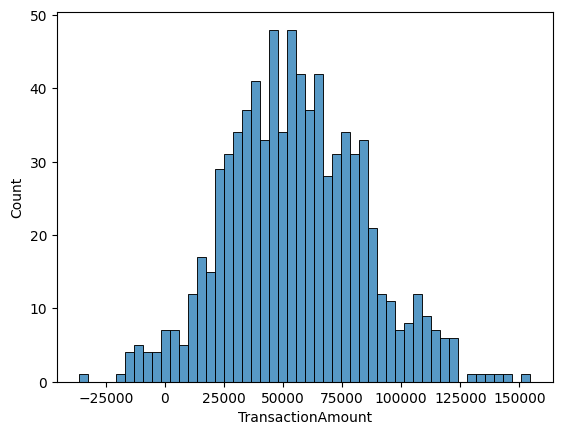

In [62]:
#Histogram

sns.histplot(df['TransactionAmount'], bins=50)
plt.show()

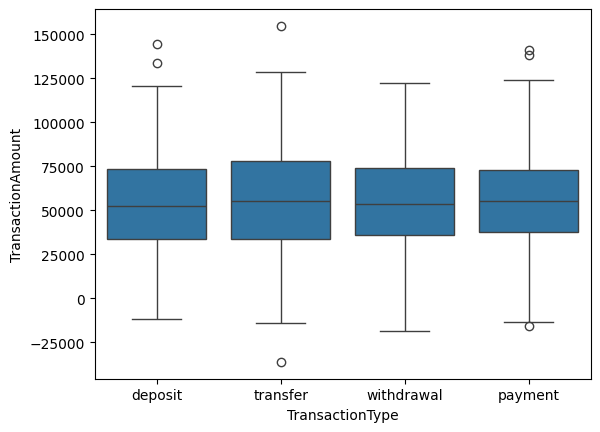

In [63]:
#Boxplot

sns.boxplot(x='TransactionType', y='TransactionAmount', data=df)
plt.show()


In [ ]:
#TASK 6: Hypothesis Testing

In [64]:
# Hypothesis Testing

from scipy.stats import ttest_ind

high = profile[profile["Activity"]=="High"]["AvgBalance"]
low = profile[profile['Activity']=="Low"]["AvgBalance"]

t, p = ttest_ind(high, low)

print("P-value:", p)

P-value: nan


C:\Users\srv\AppData\Local\Temp\ipykernel_1152\2852781614.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t, p = ttest_ind(high, low)


In [65]:
if p < 0.05:
    print("Significant difference")
else:
    print("No difference")

No difference
